# Customer Personality Analysis — Data Cleaning & EDA

**Author:** Ishtiaque Ahmed  
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Dataset:** [Customer Personality Analysis — Kaggle](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)  
**Rows:** 2,240 | **Columns:** 29

---

## Business Problem

A marketing team wants to understand which customers respond to campaigns and where their budget is being wasted. Before any analysis can happen, the raw data needs to be audited, cleaned, and structured. This notebook covers the full cleaning pipeline — from raw export to analysis-ready dataset.

---

## What I Found (Summary)

| Issue | Detail | Action Taken |
|---|---|---|
| Missing values | 24 nulls in Income (~1%) | Imputed with median |
| Impossible ages | Year_Birth = 1893 (age 130+) | Flagged and removed as outliers |
| Income outlier | One record: Income = 666,666 | Removed as data entry error |
| Dirty categories | Marital_Status: 'Absurd', 'YOLO', 'Alone' | Consolidated into standard categories |
| Wrong data type | Dt_Customer stored as string | Converted to datetime |
| Missing features | No Age or Total Spend columns | Engineered from existing columns |

**Final clean dataset: 2,236 rows, 32 columns (3 new features engineered)**

---
## 1. Import Libraries & Load Data

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')
print(f'Shape:{df.shape}')
print(df.head())
length_before = len(df)

Shape:(2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  

2. Initial Audit


In [163]:
# Null counts
print('--- Null Values ---')
print(df.isnull().sum()[df.isnull().sum() > 0])
# Dupliclates
print('\n--- Duplicated Values ---')
print(f'Total Duplicats: {df.duplicated().sum()}')
print(f'\n--- Data Types ---')
print(df.dtypes)

--- Null Values ---
Income    24
dtype: int64

--- Duplicated Values ---
Total Duplicats: 0

--- Data Types ---
ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response            

In [164]:
# Categorical columns — check unique values for dirty entries
print('Marital_Status:', df['Marital_Status'].unique())
print('Education:', df['Education'].unique())

Marital_Status: <ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str
Education: <ArrowStringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str


In [165]:
# Numeric outlier check
print('Year_Birth range:', df['Year_Birth'].min(), '-', df['Year_Birth'].max())
print('\nIncome stats:')
print(df['Income'].describe())

Year_Birth range: 1893 - 1996

Income stats:
count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64


**Audit findings:**
- `Income` has 24 nulls — will impute with median (less sensitive to outliers than mean)
- `Marital_Status` has nonsense values: `'Absurd'`, `'YOLO'`, and `'Alone'` (duplicate of Single/Together)
- `Year_Birth` minimum is 1893 — a 130-year-old customer is not real data
- `Income` maximum is 666,666 — a clear data entry error given the distribution
- `Dt_Customer` is stored as a string — needs datetime conversion

---
## 3. Fix Data Types

`Dt_Customer` is the enrollment date. It's stored as a plain string, which means you can't do any time-based analysis on it. Converting to datetime unlocks customer tenure calculations.

In [166]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst=True)
print(df['Dt_Customer'].dtype)
df['Dt_Customer'].head()

datetime64[us]


0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[us]

---
## 4. Handle Missing Values

Only `Income` has nulls — 24 rows (about 1% of the dataset). I use median imputation because the income distribution is right-skewed (the 666,666 outlier pulls the mean up). Median is more robust here.

In [167]:
median_income = df['Income'].median()
print(f'Median income is {median_income}')
df['Income'] = df['Income'].fillna(median_income)
print(f'Nulls remaining: {df["Income"].isnull().sum()}')

Median income is 51381.5
Nulls remaining: 0


---
## 5. Remove Outliers

Two clear outliers identified in the audit:
- Customers with `Year_Birth` before 1940 (age 84+) — implausible for an active marketing database
- `Income` of 666,666 — this is a data entry error (the next highest value is under 200K)

In [168]:
# The oldest customer birth years
print(f'Top 5 Oldest Birth Years:\n{df['Year_Birth'].sort_values().head(5)}')
# Top Higest Incomes
print(f'Top Higest Incomes:\n{df['Income'].sort_values(ascending=False).head(5)}')

Top 5 Oldest Birth Years:
239     1893
339     1899
192     1900
1950    1940
424     1941
Name: Year_Birth, dtype: int64
Top Higest Incomes:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
Name: Income, dtype: float64


In [169]:
print(f'Rows before outlier removal: {length_before}')

# Remove Implausible Birthyears
df = df[df['Year_Birth'] >= 1940]

# Remove Incomes Greatere Than 200k
df = df[df['Income'] <= 200000]

length_after = len(df)
print(f'Rows after outlier removal: {length_after}')
print(f'Rows removed: {length_before - length_after}')



Rows before outlier removal: 2240
Rows after outlier removal: 2236
Rows removed: 4


---
## 6. Clean Categorical Columns

`Marital_Status` has 8 unique values but only 4-5 are meaningful. `'Alone'` means the same as `'Single'`. `'Absurd'` and `'YOLO'` are clearly bad entries — I consolidate them into `'Other'` rather than dropping the rows, since the rest of the data for those customers is valid.

In [170]:
marital_map = {
    'Alone'  : 'Single',
    'Absurd' : 'Others',
    'YOLO'   : 'Others'
}
df['Marital_Status'] = df['Marital_Status'].replace(marital_map)
print('Cleaned Marital_Status values:')
print(df['Marital_Status'].value_counts())

Cleaned Marital_Status values:
Marital_Status
Married     864
Together    578
Single      482
Divorced    231
Widow        77
Others        4
Name: count, dtype: int64


---
## 7. Feature Engineering

The raw dataset doesn't have `Age`, `Total_Spend`, or `Customer_Days` — but all three can be derived from existing columns. These are the most useful features for any marketing analysis.

In [171]:
# Age from birth year
df['Age'] = 2026 - df['Year_Birth']

# Total spend across all product categories
spend_cols = [col for col in df.columns if col.startswith('Mnt')]
df['Total_Spend'] = df[spend_cols].sum(axis=1)

# Days as a customer (tenure)
reference_date = df['Dt_Customer'].max()
df['Customer_Days'] = (reference_date - df['Dt_Customer']).dt.days

print('New features added: Age, Total_Spend, Customer_Days')
df[['Age', 'Total_Spend', 'Customer_Days']].describe()


New features added: Age, Total_Spend, Customer_Days


,Age,Total_Spend,Customer_Days
count,2236.000000,2236.000000,2236.000000
mean,57.101968,605.986583,353.773256
std,11.703281,601.865156,202.181561
min,30.000000,5.000000,0.000000
25%,49.000000,69.000000,180.750000
50%,56.000000,396.500000,356.000000
75%,67.000000,1045.500000,529.000000
max,86.000000,2525.000000,699.000000


---
## 8. Final Validation

Before exporting, verify the clean dataset is in good shape.

In [172]:
print(f'Final shape: {df.shape}')
print(f'Nulls remaining: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print(f'Age range: {df["Age"].min()} - {df["Age"].max()}')
print(f'Income range: ${df["Income"].min():,.0f} - ${df["Income"].max():,.0f}')
print(f'Marital_Status values: {df["Marital_Status"].unique()}')

Final shape: (2236, 32)
Nulls remaining: 0
Duplicates: 0
Age range: 30 - 86
Income range: $1,730 - $162,397
Marital_Status values: <ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Others']
Length: 6, dtype: str


In [173]:
df.to_csv('marketing_campaign_clean.csv', index=False)
print('Clean dataset exported: marketing_campaign_clean.csv')

Clean dataset exported: marketing_campaign_clean.csv


---
## 9. Quick EDA — 3 Business Insights

Now that the data is clean, three quick visualizations that answer real business questions.

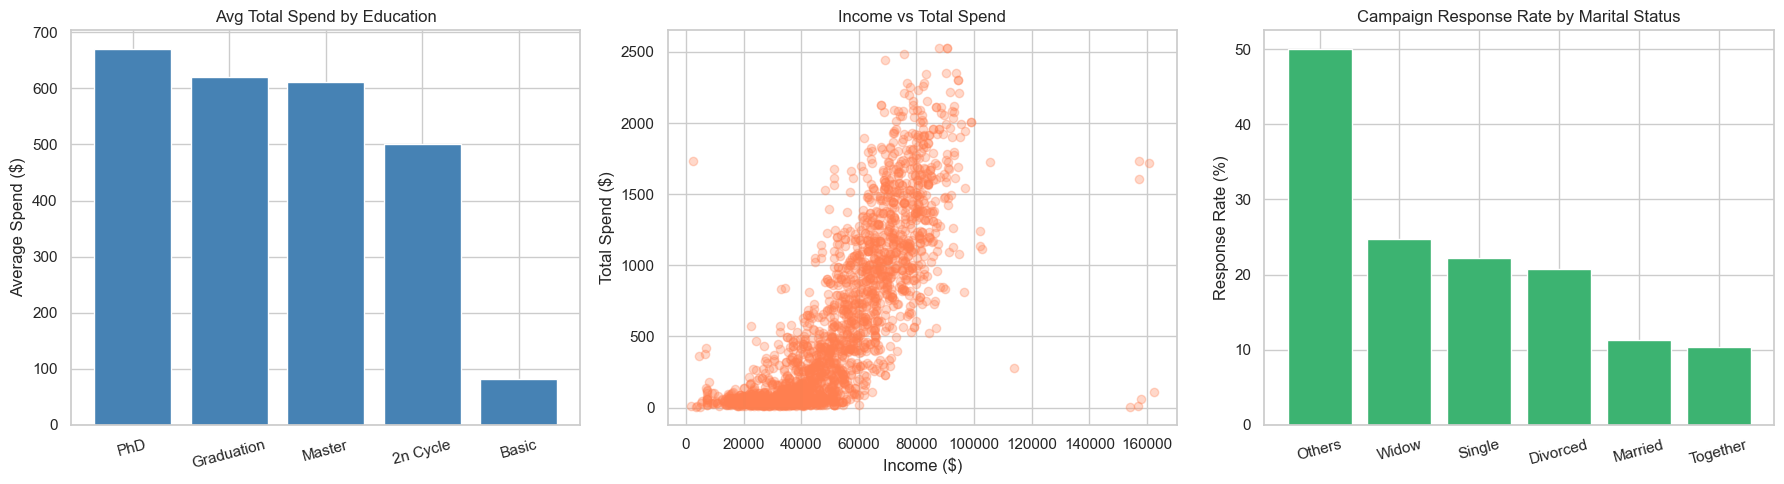

In [174]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Insight 1: Spend by Education
spend_by_edu = df.groupby('Education')['Total_Spend'].mean().sort_values(ascending=False)
axes[0].bar(spend_by_edu.index, spend_by_edu.values, color='steelblue')
axes[0].set_title('Avg Total Spend by Education')
axes[0].set_ylabel('Average Spend ($)')
axes[0].tick_params(axis='x', rotation=15)

# Insight 2: Income vs Total Spend
axes[1].scatter(df['Income'], df['Total_Spend'], alpha=0.3, color='coral')
axes[1].set_title('Income vs Total Spend')
axes[1].set_xlabel('Income ($)')
axes[1].set_ylabel('Total Spend ($)')


# Insight 3: Campaign response by Marital Status
response_by_marital = df.groupby('Marital_Status')['Response'].mean().sort_values(ascending=False)
axes[2].bar(response_by_marital.index, response_by_marital.values * 100, color='mediumseagreen')
axes[2].set_title('Campaign Response Rate by Marital Status')
axes[2].set_ylabel('Response Rate (%)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('insights.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Key Findings

1. **PhD and Master's educated customers spend significantly more** — targeting by education level could improve campaign ROI
2. **Strong positive correlation between income and spend** — high-income segments are the most valuable, but there is a cluster of low-income high-spenders worth investigating
3. **Widowed and single customers respond to campaigns at higher rates** — household composition should factor into campaign targeting

---

## Files in This Repo

| File | Description |
|---|---|
| `marketing_campaign.csv` | Raw dataset (tab-separated) |
| `marketing_campaign_clean.csv` | Clean output after all transformations |
| `marketing_campaign_cleaning.ipynb` | This notebook — full cleaning pipeline |
| `insights.png` | Output chart — 3 business insights |